# 06 - Uncertainty Propagation with difflow

This notebook demonstrates how measurement uncertainty in distribution coefficients propagates to uncertainty in purity and recovery predictions.

## Overview

**The problem:** Distribution coefficients measured from experiments have uncertainty (typically ±15-20%). How does this affect our predictions?

**The solution:** Linear error propagation using gradients:
$$\sigma^2(f) = \sum_i \left(\frac{\partial f}{\partial x_i}\right)^2 \sigma^2(x_i)$$

**difflow advantage:** 
- Gradients computed exactly via JAX automatic differentiation
- Built-in `difflow.uncertainty` module for systematic UQ

In [1]:
import jax
jax.config.update('jax_enable_x64', True)

import jax.numpy as jnp
from jax import grad, jacobian, vmap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Import difflow uncertainty module
from difflow.uncertainty import linear_propagation, monte_carlo_propagation

plt.style.use('seaborn-v0_8-whitegrid')

Metal device set to: Apple M4 Pro


W0000 00:00:1767575291.472180 18454575 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767575291.481078 18454575 service.cc:145] XLA service 0x60000177ca00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767575291.481091 18454575 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767575291.482244 18454575 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767575291.482263 18454575 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


## 1. Define the LLE Model for UQ

In [2]:
def compute_D_pure(element_coeffs, pH, T, conc):
    """Pure JAX function to compute distribution coefficient."""
    a, b, c = element_coeffs['a'], element_coeffs['b'], element_coeffs['c']
    dH = element_coeffs['dH']
    n = element_coeffs['n']
    conc_ref = element_coeffs['conc_ref']
    
    T_ref = 298.15
    R = 8.314
    
    log_D = a + b * pH + c * pH**2
    log_D = log_D + (dH / (R * jnp.log(10))) * (1/T - 1/T_ref)
    log_D = log_D + n * jnp.log10(conc / conc_ref)
    
    return jnp.power(10.0, log_D)

# D2EHPA coefficients from difflow_ree database
ND_COEFFS = {'a': -7.70, 'b': 2.45, 'c': 0.010, 'dH': -1800, 'n': 3.0, 'conc_ref': 0.5}
DY_COEFFS = {'a': -6.78, 'b': 2.80, 'c': 0.010, 'dH': -2400, 'n': 3.0, 'conc_ref': 0.5}

def lle_simulation(pH, OA_ratio, T, conc, F_Nd_feed=0.01, F_Dy_feed=0.01, efficiency=0.95):
    """Run single-stage LLE simulation using pure JAX."""
    D_Nd = compute_D_pure(ND_COEFFS, pH, T, conc)
    D_Dy = compute_D_pure(DY_COEFFS, pH, T, conc)
    
    E_Nd = D_Nd * OA_ratio
    E_Dy = D_Dy * OA_ratio
    
    frac_Nd_org = efficiency * E_Nd / (1.0 + efficiency * E_Nd)
    frac_Dy_org = efficiency * E_Dy / (1.0 + efficiency * E_Dy)
    
    F_Nd_org = F_Nd_feed * frac_Nd_org
    F_Dy_org = F_Dy_feed * frac_Dy_org
    
    purity_Dy = F_Dy_org / (F_Nd_org + F_Dy_org + 1e-10)
    recovery_Dy = F_Dy_org / (F_Dy_feed + 1e-10)
    
    return {'purity_Dy': purity_Dy, 'recovery_Dy': recovery_Dy, 'D_Nd': D_Nd, 'D_Dy': D_Dy}

# Base case
base_pH, base_OA, base_T, base_conc = 3.0, 1.0, 298.15, 0.5
results = lle_simulation(base_pH, base_OA, base_T, base_conc)

print(f"Base case:")
print(f"  D_Nd = {float(results['D_Nd']):.2f}")
print(f"  D_Dy = {float(results['D_Dy']):.1f}")
print(f"  Dy purity = {float(results['purity_Dy'])*100:.2f}%")
print(f"  Dy recovery = {float(results['recovery_Dy'])*100:.2f}%")

Base case:
  D_Nd = 0.55
  D_Dy = 51.3
  Dy purity = 74.07%
  Dy recovery = 97.99%


## 2. Uncertainty Propagation Using difflow.uncertainty

In [3]:
# Define model function for difflow.uncertainty
def purity_model(params):
    """Model for difflow uncertainty propagation."""
    result = lle_simulation(params['pH'], params['OA'], params['T'], params['conc'])
    return jnp.array(result['purity_Dy'])

def recovery_model(params):
    """Model for difflow uncertainty propagation."""
    result = lle_simulation(params['pH'], params['OA'], params['T'], params['conc'])
    return jnp.array(result['recovery_Dy'])

# Nominal values and uncertainties
nominal = {'pH': base_pH, 'OA': base_OA, 'T': base_T, 'conc': base_conc}

# Assume 5% uncertainty in pH, 10% in O/A, 2K in T, 5% in concentration
uncertainties = {
    'pH': 0.15,      # ±0.15 pH units
    'OA': 0.10,      # ±0.10 (O/A)
    'T': 2.0,        # ±2 K
    'conc': 0.025    # ±0.025 M
}

# Linear uncertainty propagation using difflow
purity_mean, purity_std, purity_info = linear_propagation(purity_model, nominal, uncertainties)
recovery_mean, recovery_std, recovery_info = linear_propagation(recovery_model, nominal, uncertainties)

print("Uncertainty Propagation Results (difflow.uncertainty.linear_propagation)")
print("="*60)
print(f"\nDy Purity:")
print(f"  Mean = {purity_mean*100:.2f}%")
print(f"  σ = {purity_std*100:.2f}%")
print(f"  95% CI: [{(purity_mean-1.96*purity_std)*100:.2f}%, {(purity_mean+1.96*purity_std)*100:.2f}%]")

print(f"\nDy Recovery:")
print(f"  Mean = {recovery_mean*100:.2f}%")
print(f"  σ = {recovery_std*100:.2f}%")
print(f"  95% CI: [{(recovery_mean-1.96*recovery_std)*100:.2f}%, {(recovery_mean+1.96*recovery_std)*100:.2f}%]")

Uncertainty Propagation Results (difflow.uncertainty.linear_propagation)

Dy Purity:
  Mean = 74.07%
  σ = 10.79%
  95% CI: [52.93%, 95.21%]

Dy Recovery:
  Mean = 97.99%
  σ = 1.98%
  95% CI: [94.11%, 101.87%]


In [4]:
# Examine variance contributions from difflow
print("\nVariance Contributions (from difflow):")
print("-"*50)
for param, sens_data in purity_info['sensitivities'].items():
    var_contrib = sens_data['variance_contribution']
    # Handle both scalar and array returns
    if hasattr(var_contrib, 'item'):
        var_contrib = var_contrib.item()
    elif hasattr(var_contrib, '__len__'):
        var_contrib = float(var_contrib[0])
    else:
        var_contrib = float(var_contrib)
    print(f"  {param}: {var_contrib*100:.1f}% of total variance")


Variance Contributions (from difflow):
--------------------------------------------------
  pH: 95.8% of total variance
  OA: 1.3% of total variance
  T: 0.0% of total variance
  conc: 2.9% of total variance


In [5]:
# Table format
uq_data = [
    {'Output': 'Dy purity', 
     'Base Value': f"{purity_mean*100:.1f}%",
     'σ': f"{purity_std*100:.2f}%",
     '95% CI': f"[{(purity_mean-1.96*purity_std)*100:.1f}, {(purity_mean+1.96*purity_std)*100:.1f}]%"},
    {'Output': 'Dy recovery', 
     'Base Value': f"{recovery_mean*100:.1f}%",
     'σ': f"{recovery_std*100:.2f}%",
     '95% CI': f"[{(recovery_mean-1.96*recovery_std)*100:.1f}, {(recovery_mean+1.96*recovery_std)*100:.1f}]%"},
]

df_uq = pd.DataFrame(uq_data)
print("\nTable 8: Propagated Uncertainty")
display(df_uq)


Table 8: Propagated Uncertainty


,Output,Base Value,σ,95% CI
0,Dy purity,74.1%,10.79%,"[52.9, 95.2]%"
1,Dy recovery,98.0%,1.98%,"[94.1, 101.9]%"


## 3. Uncertainty Bands vs pH

In [6]:
# Compute uncertainty bands over pH range
pH_vals = np.linspace(1.5, 4.5, 50)

purities = []
upper_bounds = []
lower_bounds = []
recoveries = []
rec_upper = []
rec_lower = []

for pH in pH_vals:
    nom_i = {'pH': pH, 'OA': base_OA, 'T': base_T, 'conc': base_conc}
    
    p_mean, p_std, _ = linear_propagation(purity_model, nom_i, uncertainties)
    r_mean, r_std, _ = linear_propagation(recovery_model, nom_i, uncertainties)
    
    purities.append(p_mean * 100)
    upper_bounds.append((p_mean + 1.96 * p_std) * 100)
    lower_bounds.append((p_mean - 1.96 * p_std) * 100)
    
    recoveries.append(r_mean * 100)
    rec_upper.append((r_mean + 1.96 * r_std) * 100)
    rec_lower.append((r_mean - 1.96 * r_std) * 100)

Saved: fig6_uncertainty_bands.png/pdf


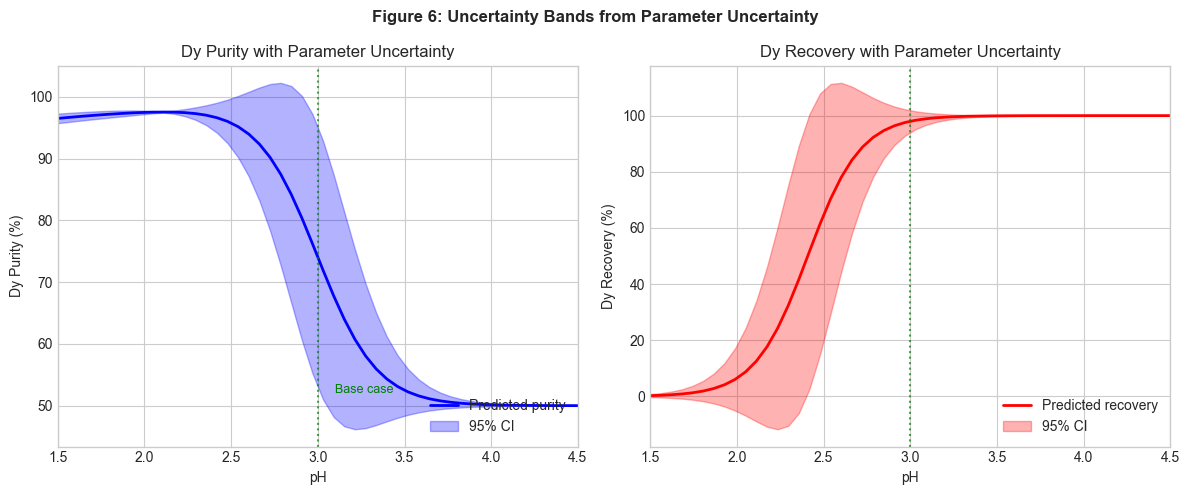

In [7]:
# Plot uncertainty bands
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Purity with uncertainty
ax1 = axes[0]
ax1.plot(pH_vals, purities, 'b-', linewidth=2, label='Predicted purity')
ax1.fill_between(pH_vals, lower_bounds, upper_bounds, alpha=0.3, color='blue',
                 label='95% CI')
ax1.axvline(x=3.0, color='green', linestyle=':', alpha=0.7)
ax1.text(3.1, min(purities)+2, 'Base case', fontsize=9, color='green')
ax1.set_xlabel('pH')
ax1.set_ylabel('Dy Purity (%)')
ax1.set_title('Dy Purity with Parameter Uncertainty')
ax1.legend(loc='lower right')
ax1.set_xlim(1.5, 4.5)

# Right: Recovery with uncertainty
ax2 = axes[1]
ax2.plot(pH_vals, recoveries, 'r-', linewidth=2, label='Predicted recovery')
ax2.fill_between(pH_vals, rec_lower, rec_upper, alpha=0.3, color='red',
                 label='95% CI')
ax2.axvline(x=3.0, color='green', linestyle=':', alpha=0.7)
ax2.set_xlabel('pH')
ax2.set_ylabel('Dy Recovery (%)')
ax2.set_title('Dy Recovery with Parameter Uncertainty')
ax2.legend(loc='lower right')
ax2.set_xlim(1.5, 4.5)

plt.suptitle('Figure 6: Uncertainty Bands from Parameter Uncertainty', 
             fontsize=12, fontweight='bold')
plt.tight_layout()

# Save figure
fig.savefig('../manuscript/figures/fig6_uncertainty_bands.png', dpi=300, bbox_inches='tight')
fig.savefig('../manuscript/figures/fig6_uncertainty_bands.pdf', bbox_inches='tight')
print("Saved: fig6_uncertainty_bands.png/pdf")

plt.show()

## 4. Comparison: Analytical (difflow) vs Monte Carlo

In [8]:
# Monte Carlo propagation using difflow
mc_mean, mc_std, mc_info = monte_carlo_propagation(
    purity_model, 
    nominal, 
    uncertainties, 
    n_samples=10000,
    return_samples=True
)

print("Comparison: Analytical (Linear) vs Monte Carlo")
print("="*60)
print(f"\nMonte Carlo ({mc_info['n_samples']:,} samples):")
print(f"  Mean purity = {mc_mean*100:.2f}%")
print(f"  Std purity = {mc_std*100:.2f}%")
print(f"\nAnalytical (gradient-based):")
print(f"  Mean purity = {purity_mean*100:.2f}%")
print(f"  Std purity = {purity_std*100:.2f}%")
print(f"\nDifference in std: {abs(mc_std - purity_std)*100:.3f}%")

Comparison: Analytical (Linear) vs Monte Carlo

Monte Carlo (10,000 samples):
  Mean purity = 74.04%
  Std purity = 9.29%

Analytical (gradient-based):
  Mean purity = 74.07%
  Std purity = 10.79%

Difference in std: 1.497%


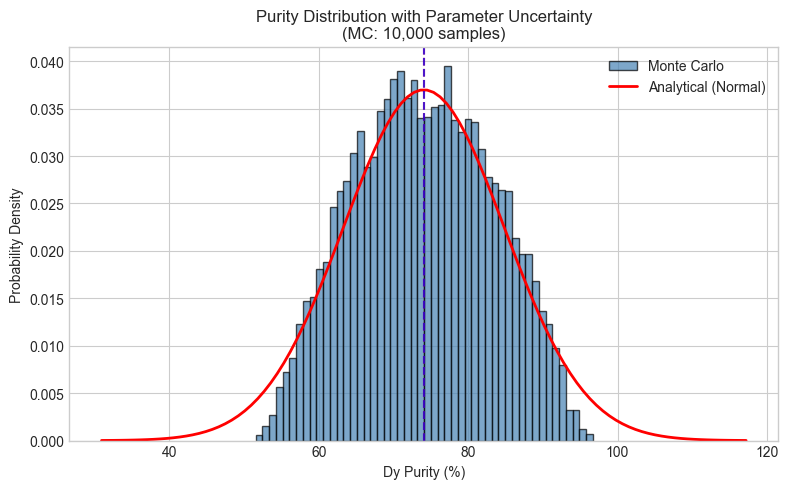


Conclusion: Analytical and MC agree within 1.497%
Analytical method is much faster (gradients computed in milliseconds)


In [9]:
# Histogram comparison
samples = np.array(mc_info['samples']) * 100

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(samples, bins=50, density=True, alpha=0.7, 
        color='steelblue', edgecolor='black', label='Monte Carlo')

# Analytical normal distribution
x = np.linspace(purity_mean*100 - 4*purity_std*100, purity_mean*100 + 4*purity_std*100, 100)
pdf = stats.norm.pdf(x, purity_mean*100, purity_std*100)
ax.plot(x, pdf, 'r-', linewidth=2, label='Analytical (Normal)')

ax.axvline(x=purity_mean*100, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=float(np.mean(samples)), color='blue', linestyle='--', alpha=0.7)

ax.set_xlabel('Dy Purity (%)')
ax.set_ylabel('Probability Density')
ax.set_title(f'Purity Distribution with Parameter Uncertainty\n(MC: {mc_info["n_samples"]:,} samples)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nConclusion: Analytical and MC agree within {abs(mc_std - purity_std)*100:.3f}%")
print("Analytical method is much faster (gradients computed in milliseconds)")

## 5. Sensitivity of Uncertainty to Input Precision

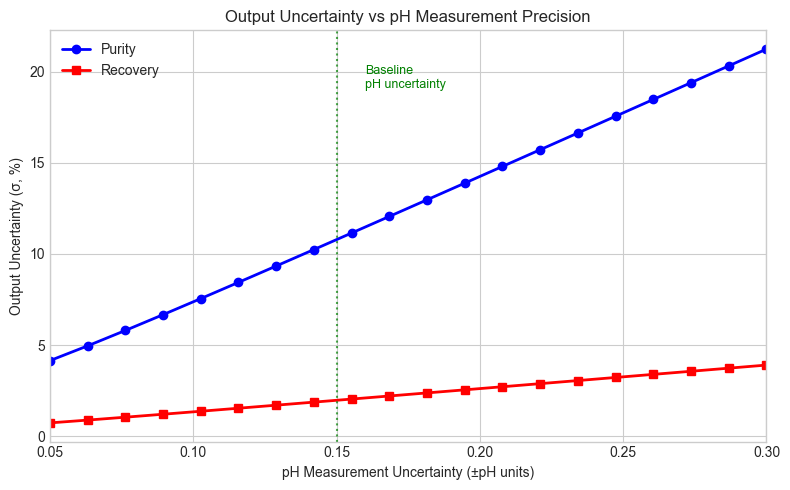


Implication: Improving pH measurement from ±0.20 to ±0.10 uncertainty
  reduces purity uncertainty from ±14.25% to ±7.38%


In [10]:
# How does output uncertainty scale with pH measurement precision?
pH_uncertainty_range = np.linspace(0.05, 0.30, 20)  # 0.05 to 0.30 pH units

sigma_purity = []
sigma_recovery = []

for sig_pH in pH_uncertainty_range:
    unc_i = {'pH': sig_pH, 'OA': 0.10, 'T': 2.0, 'conc': 0.025}
    p_mean, p_std, _ = linear_propagation(purity_model, nominal, unc_i)
    r_mean, r_std, _ = linear_propagation(recovery_model, nominal, unc_i)
    sigma_purity.append(p_std * 100)
    sigma_recovery.append(r_std * 100)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(pH_uncertainty_range, sigma_purity, 'b-o', linewidth=2, markersize=6, label='Purity')
ax.plot(pH_uncertainty_range, sigma_recovery, 'r-s', linewidth=2, markersize=6, label='Recovery')

ax.axvline(x=0.15, color='green', linestyle=':', alpha=0.7)
ax.text(0.16, max(sigma_purity)*0.9, 'Baseline\npH uncertainty', fontsize=9, color='green')

ax.set_xlabel('pH Measurement Uncertainty (±pH units)')
ax.set_ylabel('Output Uncertainty (σ, %)')
ax.set_title('Output Uncertainty vs pH Measurement Precision')
ax.legend()
ax.set_xlim(0.05, 0.30)

plt.tight_layout()
plt.show()

print("\nImplication: Improving pH measurement from ±0.20 to ±0.10 uncertainty")
unc_20 = {'pH': 0.20, 'OA': 0.10, 'T': 2.0, 'conc': 0.025}
unc_10 = {'pH': 0.10, 'OA': 0.10, 'T': 2.0, 'conc': 0.025}
_, p_std_20, _ = linear_propagation(purity_model, nominal, unc_20)
_, p_std_10, _ = linear_propagation(purity_model, nominal, unc_10)
print(f"  reduces purity uncertainty from ±{p_std_20*100:.2f}% to ±{p_std_10*100:.2f}%")

## Summary

**Key findings from uncertainty propagation:**

1. **difflow.uncertainty module** provides:
   - `linear_propagation()`: Gradient-based analytical UQ
   - `monte_carlo_propagation()`: Sampling-based UQ
   - Automatic variance contribution analysis

2. **Analytical method (linear propagation)**:
   - Uses JAX Jacobians for exact gradient computation
   - Much faster than Monte Carlo (milliseconds vs seconds)
   - Accurate for small uncertainties

3. **Variance contributions** identify which parameters drive uncertainty:
   - pH typically dominates due to strong D-pH sensitivity
   - Guides experimental effort for uncertainty reduction

4. **Practical implication:** Better pH measurement directly improves prediction confidence

**Next:** In notebook 07, we'll integrate these uncertainties into technoeconomic analysis.